# Stochastic Volatility model

## Imports & Settings

In [5]:
import warnings
warnings.filterwarnings('ignore')

In [6]:
%matplotlib inline

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns

import pymc as pm
import arviz
from pymc.distributions.timeseries import GaussianRandomWalk

In [7]:
sns.set_style('whitegrid')
# model_path = Path('models')

## Model assumptions

Asset prices have time-varying volatility (variance of day over day `returns`). In some periods, returns are highly variable, while in others very stable. Stochastic volatility models model this with a latent volatility variable, modeled as a stochastic process. The following model is similar to the one described in the No-U-Turn Sampler paper, Hoffman (2011) p21.

$$\begin{align*} 
\sigma &\sim \text{Exponential}(50)\\
\nu &\sim \text{Exponential}(.1)\\
s_i &\sim \text{Normal}(s_{i-1}, \sigma^{-2})\\
\log(r_i) &\sim t(\nu, 0, \exp(-2 s_i))
\end{align*}$$

Here, $r$ is the daily return series and $s$ is the latent log volatility process.

## Get Return Data

First we load some daily returns of the S&P 500.

In [9]:
prices = pd.read_hdf('/media/n1c0/SanDiskSSD/assets.h5', key='sp500/stooq').loc['2000':, 'close']
log_returns = np.log(prices).diff().dropna()

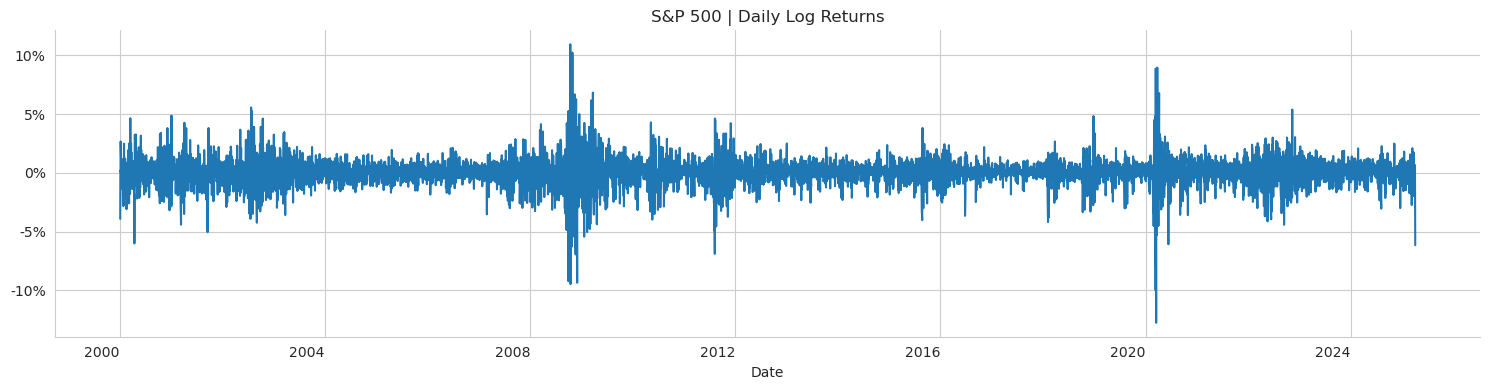

In [10]:
ax = log_returns.plot(figsize=(15, 4),
                      title='S&P 500 | Daily Log Returns',
                      rot=0)
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
sns.despine()
plt.tight_layout();

As you can see, the volatility seems to change over time quite a bit while clustering around certain time-periods, most notably the 2009 financial crash.

## Specify Model in PyMC3

Specifying the model in `PyMC3` mirrors its statistical specification. 

In [12]:
with pm.Model() as model:
    step_size = pm.Exponential('sigma', 50.)
    s = GaussianRandomWalk('s', sigma=step_size, 
                           shape=len(log_returns))
    nu = pm.Exponential('nu', .1)
    r = pm.StudentT('r', nu=nu, 
                    lam=pm.math.exp(-2*s), 
                    observed=log_returns)

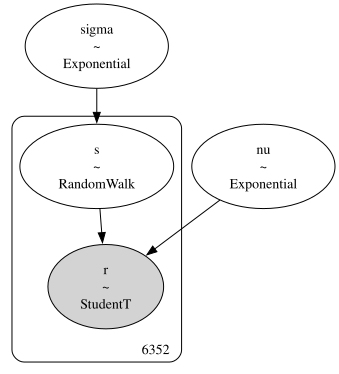

In [13]:
pm.model_to_graphviz(model)

## Fit Model

For this model, the full maximum a posteriori (MAP) point is degenerate and has infinite density. NUTS, however, gives the correct posterior.

In [14]:
with model:
    trace = pm.sample(tune=2000, 
                      draws=5000,
                      chains=4,
                      cores=1,
                      target_accept=.9)

Initializing NUTS using jitter+adapt_diag...
ERROR (pytensor.graph.rewriting.basic): Rewrite failure due to: local_subtensor_merge
ERROR (pytensor.graph.rewriting.basic): node: Subtensor{i}(Subtensor{start:stop}.0, 0)
ERROR (pytensor.graph.rewriting.basic): TRACEBACK:
ERROR (pytensor.graph.rewriting.basic): Traceback (most recent call last):
  File "/home/n1c0/anaconda3/envs/ml4t/lib/python3.12/site-packages/pytensor/graph/rewriting/basic.py", line 1922, in process_node
    replacements = node_rewriter.transform(fgraph, node)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/n1c0/anaconda3/envs/ml4t/lib/python3.12/site-packages/pytensor/graph/rewriting/basic.py", line 1086, in transform
    return self.fn(fgraph, node)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/home/n1c0/anaconda3/envs/ml4t/lib/python3.12/site-packages/pytensor/tensor/rewriting/subtensor.py", line 542, in local_subtensor_merge
    merge_two_slices(
  File "/home/n1c0/anaconda3/envs/ml4t/lib/python3.

Output()

ValueError: Not enough samples to build a trace.

Optionally, persist result as pickle:

In [ ]:
# with open('model_vol.pkl', 'wb') as buff:
#     pickle.dump({'model': model, 'trace': trace}, buff)

## Evaluate results

### Trace Plot

In [15]:
arviz.plot_trace(trace, var_names=['sigma', 'nu']);

NameError: name 'trace' is not defined

Looking at the returns over time and overlaying the estimated standard deviation we can see how the model tracks the volatility over time.

### In-Sample Predictions

In [ ]:
pm.trace_to_dataframe(trace).info()

In [ ]:
fig, ax = plt.subplots(figsize=(15, 5))

log_returns.plot(ax=ax, lw=.5, xlim=('2000', '2020'), rot=0,
                 title='In-Sample Fit of Stochastic Volatility Model')

ax.plot(log_returns.index, np.exp(trace[s]).T, 'r', alpha=.03, lw=.5)

ax.set(xlabel='Time', ylabel='Returns')
ax.legend(['S&P 500 (log returns)', 'Stochastic Volatility Model'])
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.0%}'.format(y)))

sns.despine()
fig.tight_layout()